# Detecção de lentes gravitacionais fortes: Análise Exploratória (EDA)

**Disciplina:** Processamento e Análise de Imagens, PUC-Rio
**Notebook 01 de N.** Parte do relatório final do trabalho.

## Objetivo do trabalho
Classificação binária **lente / não-lente** em recortes de imagens astronômicas
reais. Uma lente gravitacional forte ocorre quando uma galáxia massiva curva a
luz de outra galáxia atrás dela (Relatividade Geral), formando **arcos** e, no
alinhamento perfeito, um **anel de Einstein**. São eventos raríssimos; surveys
como Euclid e LSST vão gerar milhões de imagens, e a triagem manual é inviável.
Daí a motivação para um classificador automático.

## Objetivo desta EDA
Antes de treinar qualquer modelo, precisamos **conhecer o dado**. Aqui vamos:
1. Confirmar formato, faixa de valores e integridade (NaN, imagens anômalas);
2. Medir o **desbalanceamento** de classes (que decide loss e métricas);
3. Comparar **estatísticas por banda e por classe**, verificando o que separa
   (e o que *não* separa) lentes de não-lentes;
4. Caçar **duplicatas e vazamento (leakage)** entre treino e teste;
5. Definir e salvar um **split treino/validação estratificado** reprodutível.

## 1. Setup

Paths, carregamento e utilitários ficam em `src/data.py`, importado aqui; a
seed é fixada para que o notebook seja reprodutível. As estatísticas sobre o
conjunto completo são pré-computadas e mantidas em cache (`reports/*.npz`).

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
from pathlib import Path

# permite importar src/ tanto rodando de notebooks/ quanto da raiz do repo
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import data
data.set_seed()

BANDS = data.BANDS
print("bandas:", BANDS, "| shape por imagem:", data.IMG_SHAPE, "| seed:", data.SEED)

bandas: ('g', 'r', 'i') | shape por imagem: (3, 64, 64) | seed: 42


## 2. Visão geral e desbalanceamento

Os rótulos não vêm em arquivo separado: a classe está na estrutura de pastas
(`train_lenses/`, `train_nonlenses/`). `data.list_split()` percorre essas
pastas e devolve os caminhos e os rótulos correspondentes.

Convenção adotada: **lente = 1** (classe positiva) e **não-lente = 0**. É essa
escolha que define o sentido das métricas: recall passa a ser a fração das
lentes que o modelo encontrou.

In [2]:
paths_tr, y_tr = data.list_split("train")
paths_te, y_te = data.list_split("test")

print("treino:", len(paths_tr), "imagens |", int(y_tr.sum()), "lentes")
print("teste: ", len(paths_te), "imagens |", int(y_te.sum()), "lentes")
print("\nexemplo de caminho:", paths_tr[0])
print("rótulo correspondente:", y_tr[0])

treino: 30405 imagens | 1730 lentes
teste:  19650 imagens | 195 lentes

exemplo de caminho: /Users/raphaeljstaciooliveira/Stacio Technologies/Projetos/einstein-rings/data/raw/train_lenses/1.npy
rótulo correspondente: 1


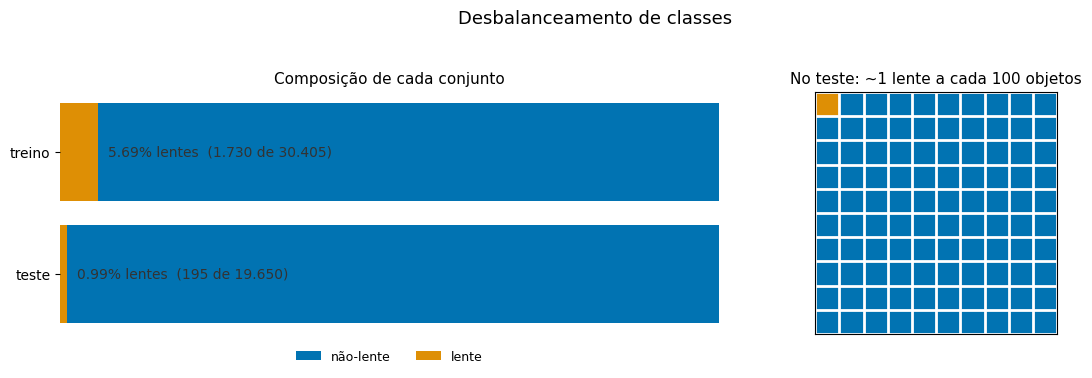

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.6),
                               gridspec_kw={"width_ratios": [1.35, 1]})

C_LENS, C_NON = "#DE8F05", "#0173B2"   # par seguro para daltonismo (validado)

# (a) composição de cada split, em proporção
splits = ["treino", "teste"]
n_lens = np.array([y_tr.sum(), y_te.sum()])
n_non = np.array([len(y_tr) - y_tr.sum(), len(y_te) - y_te.sum()])
frac_lens = n_lens / (n_lens + n_non)

ax1.barh(splits, 1 - frac_lens, left=frac_lens, color=C_NON, label="não-lente")
ax1.barh(splits, frac_lens, color=C_LENS, label="lente")
for i, f in enumerate(frac_lens):
    ax1.text(f + 0.015, i,
             f"{f:.2%} lentes  ({n_lens[i]:,} de {n_lens[i]+n_non[i]:,})".replace(",", "."),
             va="center", fontsize=10, color="#333")
ax1.set_xlim(0, 1); ax1.set_xticks([]); ax1.invert_yaxis()
ax1.set_title("Composição de cada conjunto", fontsize=11)
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2,
           frameon=False, fontsize=9)
for s in ax1.spines.values():
    s.set_visible(False)

# (b) waffle: 100 objetos do conjunto de teste, ~1 é lente
grid = np.zeros((10, 10)); grid[0, 0] = 1
ax2.imshow(grid, cmap=plt.matplotlib.colors.ListedColormap([C_NON, C_LENS]))
ax2.set_xticks(np.arange(-.5, 10, 1), minor=True)
ax2.set_yticks(np.arange(-.5, 10, 1), minor=True)
ax2.grid(which="minor", color="white", linewidth=2)
ax2.tick_params(which="both", bottom=False, left=False,
                labelbottom=False, labelleft=False)
ax2.set_title("No teste: ~1 lente a cada 100 objetos", fontsize=11)

fig.suptitle("Desbalanceamento de classes", fontsize=13, y=1.04)
plt.tight_layout()
fig.savefig("reports/figures/desbalanceamento.png", dpi=130, bbox_inches="tight")
plt.show()

### Leitura do gráfico

As duas prevalências são **diferentes de propósito**: o treino carrega 5,69% de
lentes (sinal suficiente para o modelo aprender o que é um arco), enquanto o
teste reproduz a raridade realista do céu, ~1%. Três consequências diretas para
o resto do trabalho:

1. **Acurácia é inútil como métrica.** Um classificador que responde "não-lente"
   para tudo acerta 99,0% no teste, e não encontra lente nenhuma. Vamos avaliar
   com ROC/AUC, curva precision-recall e TPR sob FPR baixo.
2. **A loss precisa compensar o desbalanceamento.** Sem peso por classe, o
   gradiente é dominado pelos negativos e o modelo converge para o chute
   trivial. Usaremos loss ponderada (ou amostragem balanceada) no treino.
3. **Precisão medida na validação será otimista.** Precisão depende da
   prevalência: o mesmo modelo, com o mesmo limiar, terá precisão bem menor no
   teste a 1% do que na validação a 5,7%. Recall e FPR, não: só a precisão se
   move. É por isso que o resultado final tem de ser reportado no conjunto de
   teste.

## 3. Formato e integridade das imagens

Cada objeto é um arquivo `.npy` de shape `(3, 64, 64)`, com as três bandas
fotométricas (g, r, i) empilhadas como canais, em `float32` normalizado no
intervalo [0, 1].

Antes de qualquer análise, verificamos o que poderia comprometer o treino em
silêncio: valores inválidos (NaN/Inf), imagens constantes (recortes que
falharam) e desvios de shape ou de faixa de valores.

In [4]:
img = data.load_image(paths_tr[0])
print("shape:", img.shape, "| dtype:", img.dtype)
print("tamanho em memória: %.1f KB" % (img.nbytes / 1024))

print("\nmin / máx / média por banda:")
for c, b in enumerate(BANDS):
    print(f"  {b}: {img[c].min():.4f} / {img[c].max():.4f} / {img[c].mean():.4f}")

print("\ncanto superior esquerdo da banda g (5x5 pixels):")
print(np.round(img[0, :5, :5], 3))

shape: (3, 64, 64) | dtype: float32
tamanho em memória: 48.0 KB

min / máx / média por banda:
  g: 0.0000 / 1.0000 / 0.2044
  r: 0.0000 / 1.0000 / 0.0695
  i: 0.0000 / 1.0000 / 0.0227

canto superior esquerdo da banda g (5x5 pixels):
[[0.201 0.218 0.172 0.16  0.2  ]
 [0.23  0.199 0.229 0.133 0.154]
 [0.137 0.18  0.152 0.13  0.131]
 [0.16  0.128 0.233 0.251 0.237]
 [0.175 0.128 0.264 0.251 0.216]]
